<a href="https://colab.research.google.com/github/Carlesoler8/carlesoler8.github.io/blob/main/Melfi_recuperacion_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Melfi — De los supuestos a la evidencia

**Autor del TFM:** Carles Soler · **Tutor:** Jaime Pineda · Máster en Analítica de Negocios (UNIE)

En este cuaderno vamos a realizar **dos análisis de ciencia de datos** para integrar mi TFM de Melfi los cuales: añaden la pieza que faltaba (datos reales + técnica analítica) y refuerzan lo que el tribunal echó en falta.

- **Bloque 1 — Análisis de reseñas de la competencia.** Descargamos reseñas reales de apps rivales (Google Play) y analizamos **de qué se quejan sus usuarios** → evidencia real.
- **Bloque 2 — Simulación del modelo financiero.** Cogemos el modelo del capítulo 7 y lo probamos contra miles de escenarios para hablar de **probabilidad y riesgo**, no de un solo escenario.

In [24]:
# --- Setup: instala las librerias ---
!pip install -q google-play-scraper scikit-learn pandas matplotlib   # descarga las librerias en Colab

import numpy as np                 # calculo numerico (arrays, numeros aleatorios)
import pandas as pd                # tablas de datos (DataFrame): como un Excel manejado por codigo
import matplotlib.pyplot as plt    # graficos
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS  # texto -> numeros (TF-IDF)
from sklearn.decomposition import NMF                                            # agrupar textos en temas

RANDOM_STATE = 14   # semilla fija -> resultados IGUALES cada vez (reproducibilidad)
print("Librerias listas.")

Librerias listas.


### ⚙️ CONFIG · Competidores y mercados

Definimos tres mercados; cada uno se analiza **por separado** con las palabras de su idioma (no se mezclan idiomas):

- **US/EN** — benchmark internacional (BetterHelp, Talkspace, Wysa).
- **ES/LATAM** — tu mercado objetivo (ifeel, TherapyChat).
- **IT** — Unobravo, que está en tu tabla T6. Es **italiana**: en español apenas tiene reseñas, así que la analizamos en **su** mercado, donde sí hay volumen.

In [25]:
# app_id = lo que va tras 'id=' en la URL de Google Play. Cada mercado lleva su idioma (lang) y pais (country).
MARKETS = {
    "US/EN":    {"lang": "en", "country": "us", "apps": {        # benchmark internacional de categoria
        "BetterHelp":  "com.betterhelp",
        "Talkspace":   "com.talkspace.talkspaceapp",
        "Wysa":        "bot.touchkin"}},
    "ES/LATAM": {"lang": "es", "country": "es", "apps": {        # tu mercado objetivo (resenas en espanol)
        "ifeel":       "com.ifeel.ifeeluserchat",
        "TherapyChat": "com.terapiachat.android"}},
    "IT":       {"lang": "it", "country": "it", "apps": {        # Unobravo (de tu T6): italiana -> aqui tiene volumen
        "Unobravo":    "com.unobravo.patient"}},
}
COUNT_PER_APP = 400   # cuantas resenas pedimos por app (las mas recientes)
# ====================================================================================================

---
# Bloque 1 — Análisis de reseñas de la competencia

**Análisis que aporta:** *Metodología* + *Estado del arte* con **datos reales** y voz de cliente para tus hipótesis de **precio** y de **cómo elige el cliente**.

**Técnicas:**
- **Web scraping** — descargar datos públicos de una web con código ([librería](https://github.com/JoMingyu/google-play-scraper)).
- **Análisis de sentimiento** — clasificar un texto como positivo/negativo. Usamos la **estrella** (1–5) como etiqueta.
- **TF-IDF** — qué palabras **caracterizan** a un grupo de textos ([doc](https://scikit-learn.org/stable/modules/feature_extraction.html#tfidf-term-weighting)).
- **Modelado de temas (NMF)** — agrupa muchos textos en sus **temas** principales ([doc](https://scikit-learn.org/stable/modules/decomposition.html#non-negative-matrix-factorization-nmf)).

### 1.1 · Bajar las reseñas

Definimos la función que baja reseñas y la ejecutamos para los tres mercados.

In [26]:
from google_play_scraper import reviews, Sort   # reviews() baja resenas; Sort.NEWEST = ordenar por fecha

def fetch_market(market, lang, country, apps, count):
    rows = []                                      # acumulamos una fila por resena
    for name, app_id in apps.items():              # recorremos cada app del mercado
        res, _ = reviews(app_id, lang=lang, country=country, sort=Sort.NEWEST, count=count)  # baja 'count' resenas
        for r in res:                              # cada r = una resena (dict: score, content, fecha...)
            if r.get("content"):                   # solo las que tienen texto
                rows.append({"market": market, "app": name,
                             "score": r["score"],      # score = estrellas (1-5)
                             "content": r["content"]})  # content = texto
        print(f"  {name:<12} {len([x for x in res if x.get('content')]):>4} resenas")
    return pd.DataFrame(rows)                       # tabla con las resenas del mercado

In [27]:
# Ejecutamos la captura para los 3 mercados y los juntamos en una sola tabla 'df'
frames = [fetch_market(m, c["lang"], c["country"], c["apps"], COUNT_PER_APP) for m, c in MARKETS.items()]
df = pd.concat(frames, ignore_index=True)          # pegamos las tablas una debajo de otra
print(f"\nTOTAL: {len(df)} resenas reales de {df.app.nunique()} apps")
df.head()                                          # primeras 5 filas, para echar un ojo a los datos

  BetterHelp    400 resenas
  Talkspace     400 resenas
  Wysa          400 resenas
  ifeel         400 resenas
  TherapyChat   400 resenas
  Unobravo      400 resenas

TOTAL: 2400 resenas reales de 6 apps


,market,app,score,content
0,US/EN,BetterHelp,3,"Therapist was cool...just...didn't connect really well and wasn't able to utilize the other aspects of the app. Its not a bad app, just not for me."
1,US/EN,BetterHelp,1,doesn't give me a chance to explore options before paying for it
2,US/EN,BetterHelp,1,haven't used their services in 6 months and still being billed after they claimed that there was an issue with my insurance company
3,US/EN,BetterHelp,5,"Excellent services, very thankful."
4,US/EN,BetterHelp,2,"they take my insurance so thats a plus but after specifically saying I need in person sessions it matched me with a therapist 2hrs away that only offers virtual, and very limited availability. I cant be sure but i beleive they use AI in their set up process to clarify your answers which I personally dont care for. If youre ok with virtual appointments and not too picky about your appointment times this might work for you. otherwise dont bother."


### 1.2 · Sentimiento desde la estrella

**1–2 = negativo · 3 = neutral · 4–5 = positivo.** Las **negativas** son la mina: ahí está lo que falla en la competencia.

In [28]:
# pd.cut reparte cada 'score' (1-5) en tres cajones segun los cortes [0,2,3,5]
df["sentiment"] = pd.cut(df.score, [0, 2, 3, 5], labels=["negativo", "neutral", "positivo"])
# % de cada sentimiento por app (proporciones que suman 1)
print(df.groupby("app", observed=True).sentiment.value_counts(normalize=True).round(2))

app          sentiment
BetterHelp   negativo     0.51
             positivo     0.44
             neutral      0.05
Talkspace    negativo     0.59
             positivo     0.34
             neutral      0.06
TherapyChat  positivo     0.83
             negativo     0.16
             neutral      0.02
Unobravo     positivo     0.72
             negativo     0.22
             neutral      0.06
Wysa         positivo     0.70
             negativo     0.26
             neutral      0.04
ifeel        positivo     0.60
             negativo     0.36
             neutral      0.04
Name: proportion, dtype: float64


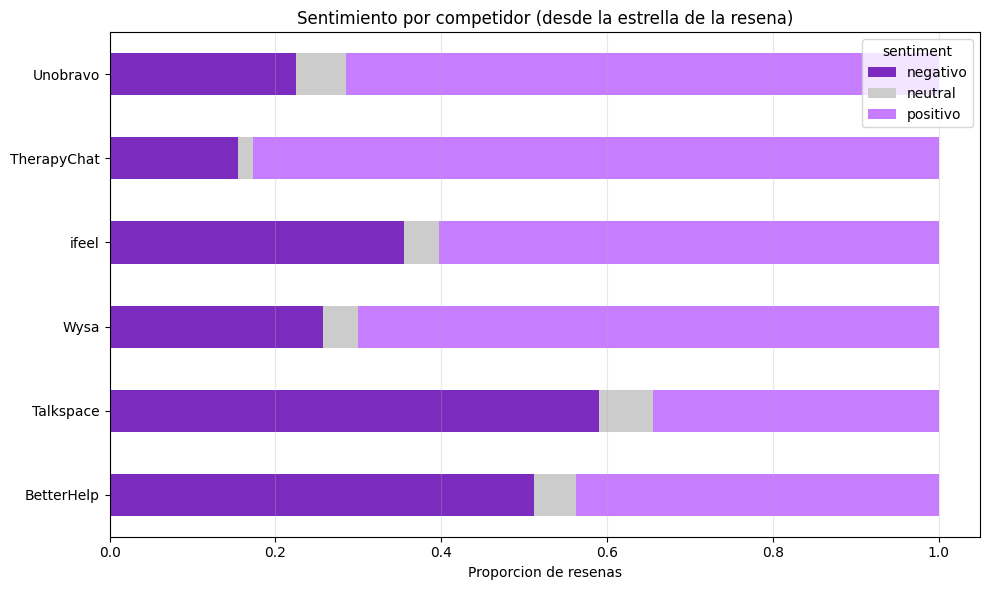

In [31]:
# Figura: % de neg/neu/pos por app (barra horizontal apilada)
order = [a for c in MARKETS.values() for a in c["apps"]]      # orden de apps = el de la CONFIG
ct = pd.crosstab(df.app, df.sentiment, normalize="index").reindex(order)[["negativo","neutral","positivo"]]
# Colores: lila oscuro (#7b2cbf) para negativo, gris (#CCCCCC) para neutral, lila claro (#c77dff) para positivo
ax = ct.plot(kind="barh", stacked=True, figsize=(10, 6), color=["#7b2cbf", "#CCCCCC", "#c77dff"])
ax.set_title("Sentimiento por competidor (desde la estrella de la resena)")
ax.set_xlabel("Proporcion de resenas"); ax.set_ylabel("")
ax.grid(True, axis="x", alpha=0.3); plt.tight_layout(); plt.show()

### 1.3 · ¿De qué se quejan? — TF-IDF + temas (NMF)

Configuramos la lógica en tres pasos: **(a)** configurar qué palabras ignorar, **(b)** definir la herramienta, **(c)** aplicarla mercado a mercado.

In [33]:
# --- 1.3a · CONFIG: palabras a IGNORAR (vacias por idioma + de dominio) ---
# Sin esto, 'the/de/di' y 'app/terapeuta' tapan las quejas reales.
SPANISH_STOP = set(("a al algo algunas algunos ante antes como con contra cual cuando de del desde donde dos el ella "
 "ellas ellos en entre era eran es esa esas ese eso esos esta estaba estan estar este esto estos ha habia han hasta hay "
 "la las le les lo los mas me mi mis mucho muy nada ni no nos o os otra otras otro otros para pero poco por porque que se "
 "sea si sin sobre solo son su sus tan te tiene tienen toda todas todo todos tu tus un una uno unos y ya estoy estas "
 "siempre nunca cosa cosas tener aqui ahi aun asi sino tambien tras durante segun aunque mientras").split())
ITALIAN_STOP = set(("a ad al allo ai agli alla alle con col coi da dal dallo dai dagli dalla dalle di del dello dei degli "
 "della delle in nel nello nei negli nella nelle su sul sullo sui sugli sulla sulle per tra fra il lo la i gli le un uno "
 "una e che non si ma se come piu poco tutto tutti ho ha hanno sono essere fare questo questa questi queste mi ti ci vi "
 "loro suo sua anche solo dopo prima quando dove perche ce non c").split())

# Palabras de DOMINIO (en/es/it): salen en TODAS las resenas del sector y no discriminan -> fuera
DOMAIN_STOP = {"therapist","therapy","app","apps","session","sessions","help","just","like","dont","doesn","didnt",
 "psychologist","talk","people","good","great","love","time","day","use","really","im","ive",
 "psicologo","psicologos","terapeuta","terapia","aplicacion","sesion","sesiones","ayuda","persona","gente","bien","bueno",
 "buena","gusta","muy","solo","vez","dia","hora","hace","hacer","puede","super","genial","excelente","recomiendo",
 "psicologa","terapeuta","seduta","seduto","applicazione","sessione","aiuto","persona","ottimo","consiglio","molto"}

def stopwords_for(lang):                              # devuelve la lista de palabras a ignorar segun el idioma
    base = {"en": ENGLISH_STOP_WORDS, "es": SPANISH_STOP, "it": ITALIAN_STOP}[lang]
    return list(set(base) | DOMAIN_STOP)
print("Listas de stop-words listas (en / es / it + dominio).")

Listas de stop-words listas (en / es / it + dominio).


In [34]:
# --- 1.3b · La herramienta: para UN mercado, saca los temas de queja (TF-IDF -> NMF) ---
def themes_for_market(sub, lang, k=4, n_terms=9):
    neg = sub[(sub.sentiment == "negativo") & (sub.content.str.len() > 15)]   # solo negativas con texto
    # TF-IDF: texto -> numeros, dando mas peso a las palabras caracteristicas de las quejas
    vec = TfidfVectorizer(ngram_range=(1, 2),         # palabras sueltas y pares de palabras
                          stop_words=stopwords_for(lang),  # ignora las palabras de la celda 1.3a (segun idioma)
                          min_df=4, max_df=0.5,        # fuera lo muy raro (<4 resenas) y lo demasiado comun (>50%)
                          strip_accents="unicode",     # 'sesion' y 'sesión' cuentan igual
                          token_pattern=r"(?u)\b[^\W\d_]{3,}\b")  # solo palabras de 3+ letras (sin numeros)
    X = vec.fit_transform(neg.content)                # X = matriz (resenas x palabras) con pesos TF-IDF
    terms = np.array(vec.get_feature_names_out())     # palabras aprendidas
    nmf = NMF(n_components=k, random_state=RANDOM_STATE, init="nndsvda", max_iter=500)  # k temas
    W = nmf.fit_transform(X)                           # W = cuanto pertenece cada resena a cada tema
    H = nmf.components_                                 # H = cuanto pesa cada palabra en cada tema
    share = pd.Series(W.argmax(axis=1)).value_counts(normalize=True)  # % de resenas en cada tema
    print(f"  {len(neg)} resenas negativas | {k} temas:")
    topics = {}
    for t in range(k):
        words = list(terms[H[t].argsort()[::-1][:n_terms]])  # las palabras de mas peso del tema
        topics[t] = words
        print(f"   Tema {t} ({share.get(t,0):4.0%}): {', '.join(words)}")
    return topics
print("Herramienta lista. La aplicamos mercado a mercado en la siguiente celda.")

Herramienta lista. La aplicamos mercado a mercado en la siguiente celda.


In [35]:
# --- 1.3c · Aplicar la herramienta a CADA mercado por separado ---
topics_by_market = {}
for m, cfg in MARKETS.items():
    print(f"\n=== {m} ===")
    topics_by_market[m] = themes_for_market(df[df.market == m], cfg["lang"])


=== US/EN ===
  526 resenas negativas | 4 temas:
   Tema 0 ( 61%): money, therapists, didn, week, free, pay, got, need, charged
   Tema 1 ( 14%): insurance, don, subscription, accept, cover, payment, information, covered, talkspace
   Tema 2 ( 13%): service, customer, customer service, terrible, billing, support, buggy, worst, customer support
   Tema 3 ( 12%): update, open, won, screen, telling, keeps, missed, white, white screen

=== ES/LATAM ===
  187 resenas negativas | 4 temas:
   Tema 0 ( 22%): dinero, tienes, quieren, mala, siquiera, tiempo, nadie, verdad, mal
   Tema 1 ( 16%): pagar, gratis, tienes, hablar, realmente, consulta, pense, opcion, servicio
   Tema 2 (  9%): edad, menores, menores edad, menor, menor edad, pueden, padres, dar, soy
   Tema 3 ( 52%): puedo, deja, dice, cuenta, problema, tengo, iniciar, funciona, despues

=== IT ===
  88 resenas negativas | 4 temas:
   Tema 0 ( 56%): all, appuntamento, volta, ogni, dell, primo, assolutamente, chi, pagamento
   Tema 1 ( 

### 1.4 · De la queja del competidor a la palanca de Melfi


In [36]:
# Reglas: (palabras_pista, nombre_de_la_brecha, respuesta_de_Melfi). Incluyen pistas en EN / ES / IT.
GAP_RULES = [
 (["expensive","cost","money","price","afford","subscription","caro","precio","pagar","cobran","dinero","gratis",
   "reembolso","prezzo","costoso","abbonamento","soldi","rimborso","pagare","costa"],
  "Precio", "Arbitraje LATAM: ~25 EUR/sesion vs 45-65 EUR de la competencia"),
 (["match","choose","switch","fit","random","assigned","elegir","asignan","cambiar","afinidad","scegliere","cambiare"],
  "Asignacion", "Asignacion por afinidad (sin paralisis de eleccion)"),
 (["wait","booking","book","availability","appointment","espera","cita","agendar","reservar","tarda","demora",
   "appuntamento","attesa","prenotare","disponibilita","aspettare"],
  "Inmediatez", "Slots reales el mismo dia (on-demand)"),
 (["rushed","short","late","cancel","unprofessional","corto","tarde","cancelan","manipularon","pesimos","experiencia",
   "scadente","pessimo","professionale"],
  "Calidad/vetting", "Vetting de psicologos + valoracion post-sesion"),
 (["crash","buggy","login","glitch","update","screen","falla","error","cuelga","lenta","entrar","iniciar","cuenta",
   "correo","errore","accedere","account","bloccato","aggiornamento"],
  "Tecnico/UX", "Infra estable + prototipo cuidado (landing en anexo)"),
]
for m, topics in topics_by_market.items():
    print(f"\n[{m}]  brecha del competidor -> respuesta de Melfi")
    seen = set()
    for t, words in topics.items():
        blob = " ".join(words)                          # palabras del tema juntas en un texto
        best = max(GAP_RULES, key=lambda r: sum(w in blob for w in r[0]))  # la regla con mas pistas coincidentes
        if sum(w in blob for w in best[0]) and best[1] not in seen:
            print(f"   {best[1]:<14} <- {', '.join(words[:4])}")
            print(f"   {'':14}    Melfi: {best[2]}")
            seen.add(best[1])


[US/EN]  brecha del competidor -> respuesta de Melfi
   Precio         <- money, therapists, didn, week
                     Melfi: Arbitraje LATAM: ~25 EUR/sesion vs 45-65 EUR de la competencia
   Tecnico/UX     <- service, customer, customer service, terrible
                     Melfi: Infra estable + prototipo cuidado (landing en anexo)

[ES/LATAM]  brecha del competidor -> respuesta de Melfi
   Precio         <- dinero, tienes, quieren, mala
                     Melfi: Arbitraje LATAM: ~25 EUR/sesion vs 45-65 EUR de la competencia
   Tecnico/UX     <- puedo, deja, dice, cuenta
                     Melfi: Infra estable + prototipo cuidado (landing en anexo)

[IT]  brecha del competidor -> respuesta de Melfi
   Inmediatez     <- all, appuntamento, volta, ogni
                     Melfi: Slots reales el mismo dia (on-demand)
   Precio         <- pessima, esperienza, soldi, assistenza
                     Melfi: Arbitraje LATAM: ~25 EUR/sesion vs 45-65 EUR de la competencia


In [37]:
# Para que salgan las reseñas completas
import pandas as pd
pd.set_option('display.max_colwidth', None)
df.to_csv("reseñas_melfi.csv")

In [38]:
df[(df.app=="ifeel") & (df.sentiment=="negativo")].content.sample(15)

,content
1529,He tratado de instalarla y no me deja. Alguien tiene el mismo problema?
1465,Encuentro que deberían dar la opción para menores de edad ya que las emociones las siente cualquiera
1203,"La app tiene muchas inconsistencias, una atención algo tardada."
1212,"pésima aplicación un dia te deja entrar y al siguente te mande mensaje de error ""nil user"""
1217,cada mes tengo que desinstalar e instalar la app porque no me deja ingresar nuncaaaaa 😡
1213,"Cuando intento abrir la app se cierra de golpe y no llega a abrir, he probado a desinstalar e instalar pero no ha funcionado"
1310,"Vaya timo. Desde luego, más caro e inútil que comprar piedras. Las consultas privadas valen 200€, pero esque almenos haces consultas. Y los más de 300 estrategias las busco en Google y listo. Madre mía desde luego..."
1299,"El terapeuta tras 7 sesiones no es capaz de dar un diagnóstico, la aplicación falla muchísimo y se ha caído varias veces la videollamada en medio de la terapia, los cobros son automáticos y se renuevan cada mes cuando te dice que ""contratas cuatro sesiones"" Aún estoy esperando que me deje hablar con el terapeuta para dar la última sesión que YA he pagado... No te lo puedes tomar en serio. Sirve para desahogarse, pero ya está. Mejor ir a un presencial. Necesita mejorar mucho."
1235,Espere mas de una hora para que apareciera el psicologo y no aparecio
1417,Es malisima la estaba descargando para ayudar a alguirn y cuando llega la descarga 100% no se instala porfaboor arreglen eso


In [39]:
df[(df.app=="TherapyChat") & (df.sentiment=="negativo")].content.sample(15)

,content
1996,"El chat es horrible, tiene bugs al escribir, no se envia correctamente o no se envia. Al redactar el texto se borra si sales de la pantalla. En videollamada se corta si sales de la aplicacion, no puedes hacer nada en segundo plano como leer notas apuntadas en agenda o evernote"
1829,"Cambio la calificación anterior. Las dos terapeutas que me han tocado están muy preparadas, muy atentas, te dan un plan de trabajo personalizado, desde las primeras sesiones sentí la diferencia, que lástima que tenga tantas fallas en el sistema, no llegan notificaciones, las llamadas se caen aunque haya buen internet, los cobros se hacen dobles, se cancela la suscripción sin motivo alguno, me he tenido que quedar sin terapia por varias semanas por estos detalles. Ojalá mejoren."
1798,No puedo iniciar sesión del móvil pese a tener la cuenta creada
1607,"Pésima atención al paciente por parte de la plataforma (las psicólogas son geniales), cobros de más, errores ""poco frecuentes"" según ellos."
1795,No puedo iniciar sesión ni crear una cuenta nueva. Me vuelve a la pantalla de inicio de sesión
1837,"CUIDADO Te hacen cargos no autorizados en la tarjeta, anulé la suscripción tras concertar la sesión de prueba que al final no se produjo y me han cargado 117 euros, y eso que abrí un ticket días antes indicándoles la razón de mi baja. Sicologos sudamericanos. Actualizo, ahora me dicen, cuando hay un ticket creado de hace 8 dias que no les consta la baja y que me ponga yo en contacto con la sicologa para que si le parece bien me devuelva el dinero.... Ya me han devuelto el dinero, dicen que habian duplicado mi usuario y mis datos. El caso es que sigo si poder cancelar la cuenta..."
1922,"The sound and video image worked bad in 3 out if 4 sessions, which is needed for communicate appropriately with your therapist. Also, to assign you a therapist, you only provide one hashtag when problems have usually more than one side. As a patient, you might not really know what you are experiencing so as to put it a label. One single hashtag determines the professional you are assigned to. I have absolutely no complaints about the professional I got on the other side, but the app"
1608,"El concepto es genial, y las sanitarias de 10, pero la aplicación cada vez va peor, no llegan mensajes, se cortan las llamadas, se queda pillado, y con cada actualización me da la sensación que es peor..."
1800,"No he visto app más inutil en toda mi vida, se anuncian como una app gratuita y en realidad hay que pagar un premium. Si van a hacer una app de pago no digan que es gratuita ,vaya manera de timar y hacer perder el tiempo a personas como yo ,que buscamos ayuda con el móvil porque no tenemos tiempo ni dinero para encontrarla por otros medios ."
1773,"No deja registrarse... despues de escribir toda la historia... Te pide el email para registrar, y al escribir el propio, me dice constantemente que no es valido. Vaya... que no puedo usar la app."


---
# Bloque 2 — Simulación de tu modelo financiero (Monte Carlo)

**Aporta:** *Metodología* cuantitativa y refuerza el *plan financiero* (cap. 7).

**Monte Carlo:** en vez de **un** número por supuesto, metes un **rango** y el ordenador prueba miles de combinaciones. Se obtiene la **distribución** de resultados → vemos la **probabilidad** de ser rentable y el **riesgo** de no serlo
([referencia](https://en.wikipedia.org/wiki/Monte_Carlo_method)).

### 2.1 · Modelo de supuestos + validación

Dos pasos: **(a)** supuestos, **(b)** la fórmula del margen, **(c)** comprobacion que es lo que hay en la memoria.

In [40]:
# --- 2.1a · CONFIG: tus supuestos como (minimo, valor_central, maximo). Se usan como RANGO al simular ---
CFG = {
    "sessions_month":   (700, 1650, 2600),    # sesiones/mes: tu escenario pesimista / base / optimista (T11)
    "price_b2c":        (20, 25, 30),          # precio por sesion al cliente final (T10)
    "pay_psychologist": (10, 12, 14),          # lo que cobra el psicologo por sesion (T10)
    "op_cost_session":  (1.5, 2.0, 3.0),       # coste operativo por sesion (T10)
    "b2b2c_commission": (0.10, 0.15, 0.20),    # comision del canal empresa B2B2C (T10)
    "premium_month":    (60, 70, 80),          # precio del plan Premium/mes, incluye 3 sesiones (T10)
    "fixed_cost":       (6000, 7000, 9000),    # costes fijos al mes (T11)
}
MIX_BASE = np.array([0.25, 0.45, 0.30])    # % de sesiones por linea de negocio: B2C / B2B2C / Premium

In [41]:
# --- 2.1b · La formula: margen de contribucion por sesion, mezclando las tres lineas segun su peso ---
def blended_margin(price, pay, op, comm, prem, mix):
    m_b2c   = price - pay - op                       # B2C    = precio - pago psicologo - coste operativo
    m_b2b2c = price * (1 - comm) - pay - op           # B2B2C  = el canal se queda una comision sobre el precio
    m_prem  = prem / 3 - pay - op                     # Premium= 70 EUR / 3 sesiones = precio efectivo por sesion
    mix = np.asarray(mix)
    if mix.ndim == 1:                                 # 1 escenario: mix es un vector de 3 pesos
        return mix[0]*m_b2c + mix[1]*m_b2b2c + mix[2]*m_prem
    return mix[:,0]*m_b2c + mix[:,1]*m_b2b2c + mix[:,2]*m_prem   # miles de escenarios a la vez

In [42]:
# --- 2.1c · Validacion: con el valor CENTRAL de cada supuesto ---
mode = {k: v[1] for k, v in CFG.items()}             # valor central (posicion 1) de cada rango
m_blended = blended_margin(mode["price_b2c"], mode["pay_psychologist"], mode["op_cost_session"],
                           mode["b2b2c_commission"], mode["premium_month"], MIX_BASE)
breakeven = mode["fixed_cost"] / m_blended            # sesiones para cubrir costes = costes fijos / margen
print(f"Margen mezclado : {m_blended:.2f} EUR/sesion   (tu memoria: 8,81)")
print(f"Break-even      : {breakeven:.0f} sesiones/mes  (tu memoria: ~795)")
for name, ses, ref in [("Pesimista",700,-831),("Base",1650,7541),("Optimista",2600,15912)]:
    eb = m_blended*ses - mode["fixed_cost"]           # EBITDA = margen * sesiones - costes fijos
    print(f"  {name:<10} {ses:>5} ses -> EBITDA {eb:>8.0f} EUR   (memoria: {ref})")

Margen mezclado : 8.81 EUR/sesion   (tu memoria: 8,81)
Break-even      : 794 sesiones/mes  (tu memoria: ~795)
  Pesimista    700 ses -> EBITDA     -831 EUR   (memoria: -831)
  Base        1650 ses -> EBITDA     7541 EUR   (memoria: 7541)
  Optimista   2600 ses -> EBITDA    15912 EUR   (memoria: 15912)


### 2.2 · La simulación (10.000 escenarios)

Cada supuesto pasa a ser una **distribución triangular** (más peso en la moda). Dos pasos: **(a)** simular y medir probabilidad de beneficio, **(b)** ver la distribución y qué palanca pesa más.

In [43]:
# --- 2.2a · Simular 10.000 escenarios y medir probabilidad de beneficio ---
N = 10_000                                     # numero de escenarios
rng = np.random.default_rng(RANDOM_STATE)      # generador aleatorio con semilla fija (reproducible)
# triangular(min, moda, max): mas probable cerca del centro, menos en los extremos
s = {k: rng.triangular(*v, N) for k, v in CFG.items()}
mix = rng.dirichlet(MIX_BASE * 60, N)          # N mezclas de lineas distintas alrededor de MIX_BASE
margin = blended_margin(s["price_b2c"], s["pay_psychologist"], s["op_cost_session"],
                        s["b2b2c_commission"], s["premium_month"], mix)   # margen de cada escenario
ebitda_m = margin * s["sessions_month"] - s["fixed_cost"]   # EBITDA mensual de cada escenario
be = s["fixed_cost"] / margin                  # sesiones para break-even en cada escenario

print(f"P(EBITDA mensual > 0) = {(ebitda_m > 0).mean():.0%}")   # % de escenarios con beneficio
be5, be50, be95 = np.percentile(be, [5, 50, 95])                # percentiles 5/50/95 del break-even
print(f"Sesiones/mes para break-even -> mediana {be50:,.0f} (rango {be5:,.0f}-{be95:,.0f})")
print(f"Tu escenario base asume {CFG['sessions_month'][1]:,} -> {CFG['sessions_month'][1]/be50:.1f}x el break-even")

P(EBITDA mensual > 0) = 96%
Sesiones/mes para break-even -> mediana 847 (rango 618-1,268)
Tu escenario base asume 1,650 -> 1.9x el break-even


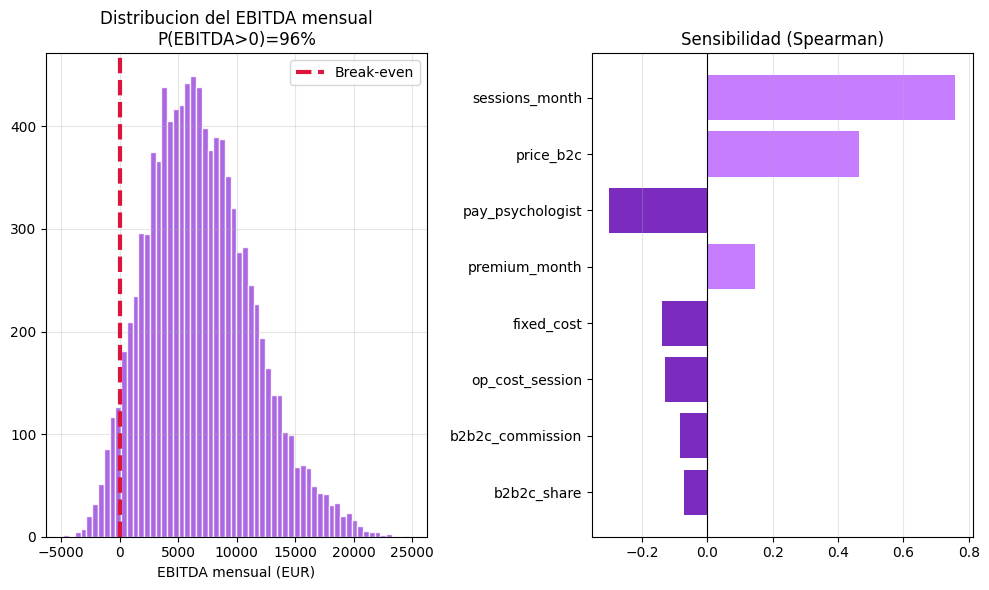

sessions_month      0.76
price_b2c           0.47
pay_psychologist   -0.30
premium_month       0.15
fixed_cost         -0.14
op_cost_session    -0.13
b2b2c_commission   -0.08
b2b2c_share        -0.07
Name: ebitda_m, dtype: float64


In [47]:
# --- 2.2b · Ver la distribucion y la sensibilidad (que palanca mueve mas el EBITDA) ---
sim = pd.DataFrame(s); sim["b2b2c_share"] = mix[:,1]; sim["ebitda_m"] = ebitda_m   # tabla supuestos + EBITDA
corr = sim.corr(method="spearman")["ebitda_m"].drop("ebitda_m")    # correlacion de cada supuesto con el EBITDA
corr = corr.reindex(corr.abs().sort_values(ascending=False).index) # ordenar por importancia (valor absoluto)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))   # dos graficos lado a lado
# Izquierda: histograma = como se reparten los 10.000 EBITDA posibles
# Color lila (#9d4edd) para las barras y rojo (crimson) para la linea de break-even
axes[0].hist(ebitda_m, bins=60, color="#9d4edd", edgecolor="white", alpha=.85)
axes[0].axvline(0, color="crimson", ls="--", lw=3, label="Break-even")   # linea en EBITDA = 0
axes[0].set_title(f"Distribucion del EBITDA mensual\nP(EBITDA>0)={(ebitda_m>0).mean():.0%}")
axes[0].set_xlabel("EBITDA mensual (EUR)"); axes[0].legend(); axes[0].grid(True, alpha=.3)
# Derecha: barras = sensibilidad (lila oscuro baja el EBITDA, lila claro lo sube)
axes[1].barh(corr.index[::-1], corr.values[::-1], color=["#7b2cbf" if v < 0 else "#c77dff" for v in corr.values[::-1]])
axes[1].axvline(0, color="black", lw=.8); axes[1].set_title("Sensibilidad (Spearman)"); axes[1].grid(True, axis="x", alpha=.3)
plt.tight_layout(); plt.show()
print(corr.round(2))                              # tabla de correlaciones ordenada por importancia